## Autoencoder Concolucional 1D para filtrado de Ruido de Señales de PPG

# Alumno: Victoria Galvan Delgadillo.

In [4]:
import os 
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import tensorflow as tf 
from tensorflow.keras import layers, models, callbacks

#Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Tensorflow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU DETECTADA:", gpus if gpus else "Ninguna: Se ejecutara en CPU") 

Tensorflow: 2.20.0
GPU DETECTADA: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Ingresamos los datos 
Cargamos los datos desde el disco, descargamos manualmente el 'PPG.csv'. 

In [5]:
DATA_DIR = "/home/victoria/welltory-ppg-dataset/data"  

csv_paths = sorted(glob.glob(f"{DATA_DIR}/subject_*/PPG.csv"))
assert len(csv_paths) > 0, (
    f"No se encontraron archivos PPG.csv en {DATA_DIR}/subject_*/. "
)
print(f"Archivos PPG.csv encontrados: {len(csv_paths)}")
for p in csv_paths:
    print(" -", p)


Archivos PPG.csv encontrados: 21
 - /home/victoria/welltory-ppg-dataset/data/subject_01/PPG.csv
 - /home/victoria/welltory-ppg-dataset/data/subject_02/PPG.csv
 - /home/victoria/welltory-ppg-dataset/data/subject_03/PPG.csv
 - /home/victoria/welltory-ppg-dataset/data/subject_04/PPG.csv
 - /home/victoria/welltory-ppg-dataset/data/subject_05/PPG.csv
 - /home/victoria/welltory-ppg-dataset/data/subject_06/PPG.csv
 - /home/victoria/welltory-ppg-dataset/data/subject_07/PPG.csv
 - /home/victoria/welltory-ppg-dataset/data/subject_08/PPG.csv
 - /home/victoria/welltory-ppg-dataset/data/subject_09/PPG.csv
 - /home/victoria/welltory-ppg-dataset/data/subject_10/PPG.csv
 - /home/victoria/welltory-ppg-dataset/data/subject_11/PPG.csv
 - /home/victoria/welltory-ppg-dataset/data/subject_12/PPG.csv
 - /home/victoria/welltory-ppg-dataset/data/subject_13/PPG.csv
 - /home/victoria/welltory-ppg-dataset/data/subject_14/PPG.csv
 - /home/victoria/welltory-ppg-dataset/data/subject_15/PPG.csv
 - /home/victoria/well

In [9]:
dfs = []
for path in csv_paths:
    subject_id = path.split(os.sep)[-2]  
    df_i = pd.read_csv(path)
    df_i["subject_id"] = subject_id
    dfs.append(df_i)

df_raw = pd.concat(dfs, ignore_index=True)
print("Shape combinado (21 sujetos):", df_raw.shape)
print("Sujetos:", sorted(df_raw['subject_id'].unique()))
df_raw.head()

Shape combinado (21 sujetos): (51530, 5)
Sujetos: ['subject_01', 'subject_02', 'subject_03', 'subject_04', 'subject_05', 'subject_06', 'subject_07', 'subject_08', 'subject_09', 'subject_10', 'subject_11', 'subject_12', 'subject_13', 'subject_14', 'subject_15', 'subject_16', 'subject_17', 'subject_18', 'subject_19', 'subject_20', 'subject_21']


,time,R,G,B,subject_id
0,0,252.650,0.0,0.012,subject_01
1,39,252.556,0.0,0.014,subject_01
2,62,252.228,0.0,0.014,subject_01
3,89,252.135,0.0,0.011,subject_01
4,120,252.332,0.0,0.012,subject_01


In [10]:
candidates = [c for c in df_raw.columns if 'red' in c.lower()]
print("Columnas candidatas para canal Red:", candidates)

RED_COL = candidates[0] if candidates else df_raw.columns[1]  # fallback: segunda columna
print("Columna usada como canal Red:", RED_COL)

Columnas candidatas para canal Red: []
Columna usada como canal Red: R


## Pre-procesamiento
- Segmentamos la señal RED en ventanas de 128 pasos no solapadas por sujeto, para no generar ventanas que mezclen la señal de dos pacientes distintos. 
- Aplicamos Min-Max scaling por ventana llevando cada ventana a [0,1]. Esto ayuda a evityar que la escala global de la señal domine el aprendizaje.


In [11]:
WINDOW_SIZE = 128

def segment_signal(signal, window_size=WINDOW_SIZE):
    n_windows = len(signal) // window_size
    signal = signal[: n_windows * window_size]
    return signal.reshape(n_windows, window_size)

all_windows = []
all_subject_ids = []

for subject_id, group in df_raw.groupby("subject_id", sort=True):
    red_signal = group[RED_COL].astype(float).dropna().to_numpy()
    subject_windows = segment_signal(red_signal, WINDOW_SIZE)
    all_windows.append(subject_windows)
    all_subject_ids.extend([subject_id] * len(subject_windows))
    print(f"{subject_id}: {len(red_signal)} muestras -> {len(subject_windows)} ventanas")

windows = np.concatenate(all_windows, axis=0)
subject_ids_per_window = np.array(all_subject_ids)

print("\nVentanas totales (21 sujetos combinados):", windows.shape)  # ventana 128 

subject_01: 3155 muestras -> 24 ventanas
subject_02: 2212 muestras -> 17 ventanas
subject_03: 2219 muestras -> 17 ventanas
subject_04: 2366 muestras -> 18 ventanas
subject_05: 2488 muestras -> 19 ventanas
subject_06: 2429 muestras -> 18 ventanas
subject_07: 2529 muestras -> 19 ventanas
subject_08: 2417 muestras -> 18 ventanas
subject_09: 2579 muestras -> 20 ventanas
subject_10: 2710 muestras -> 21 ventanas
subject_11: 2613 muestras -> 20 ventanas
subject_12: 2044 muestras -> 15 ventanas
subject_13: 2351 muestras -> 18 ventanas
subject_14: 2418 muestras -> 18 ventanas
subject_15: 2629 muestras -> 20 ventanas
subject_16: 2840 muestras -> 22 ventanas
subject_17: 2683 muestras -> 20 ventanas
subject_18: 2506 muestras -> 19 ventanas
subject_19: 2153 muestras -> 16 ventanas
subject_20: 2086 muestras -> 16 ventanas
subject_21: 2103 muestras -> 16 ventanas

Ventanas totales (21 sujetos combinados): (391, 128)


In [12]:
def minmax_scale_per_window(windows, eps=1e-8):
    """Escala cada ventana individualmente al rango [0, 1] (escalado local)."""
    w_min = windows.min(axis=1, keepdims=True)
    w_max = windows.max(axis=1, keepdims=True)
    return (windows - w_min) / (w_max - w_min + eps)

windows_scaled = minmax_scale_per_window(windows)
print("Rango tras escalado:", windows_scaled.min(), windows_scaled.max())

# Forma requerida por Conv1D: (n_muestras, pasos_tiempo, canales)
X = windows_scaled[..., np.newaxis].astype("float32")
print("Shape final X:", X.shape)

Rango tras escalado: 0.0 0.999999999815607
Shape final X: (391, 128, 1)


## Ruido Gaussiano 
Se implementa ruido gaussiano con desviacion estandar equivalente al 15% del rango de la señal que tras el escalado Min-Max es 1.0, simulando interferencia del sensor óptico. El resultado se recorta a [0,1] para mantener el mismo rango de la señal limpiada. 

In [13]:
NOISE_LEVEL = 0.15

def add_gaussian_noise(X, noise_level=NOISE_LEVEL, seed=SEED):
    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=0.0, scale=noise_level, size=X.shape)
    X_noisy = X + noise
    return np.clip(X_noisy, 0.0, 1.0).astype("float32")

X_noisy = add_gaussian_noise(X)
print("Shape señal ruidosa:", X_noisy.shape)


Shape señal ruidosa: (391, 128, 1)


## Split entrenaminto / Valicación / Test 
Con 21 sujetos distintos, el split hace a nivel de sujeto (no a nivel de ventana): todas las ventanas de un mismo paciente quedan en entrenamiento, validación o test. Así evitamos que el ruido del modelo vea fragmentos de un mismo paciente en entrenamiento y test (perdida de datos), lo cual daría una evaluación demasiado optimista.

In [14]:
from sklearn.model_selection import GroupShuffleSplit

unique_subjects = np.unique(subject_ids_per_window)
print("Sujetos totales:", len(unique_subjects))

# 70% sujetos -> train, 30% -> temp (luego partido en val/test)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(gss1.split(X, groups=subject_ids_per_window))

# de ese 30%, la mitad para val y la mitad para test (a nivel de sujeto también)
temp_groups = subject_ids_per_window[temp_idx]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_rel_idx, test_rel_idx = next(gss2.split(temp_idx, groups=temp_groups))
val_idx = temp_idx[val_rel_idx]
test_idx = temp_idx[test_rel_idx]

X_train_clean, X_train_noisy = X[train_idx], X_noisy[train_idx]
X_val_clean, X_val_noisy = X[val_idx], X_noisy[val_idx]
X_test_clean, X_test_noisy = X[test_idx], X_noisy[test_idx]

print("Sujetos en train:", sorted(set(subject_ids_per_window[train_idx])))
print("Sujetos en val:  ", sorted(set(subject_ids_per_window[val_idx])))
print("Sujetos en test: ", sorted(set(subject_ids_per_window[test_idx])))
print()
print("Train:", X_train_clean.shape)
print("Val:  ", X_val_clean.shape)
print("Test: ", X_test_clean.shape)

Sujetos totales: 21
Sujetos en train: [np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05'), np.str_('subject_07'), np.str_('subject_08'), np.str_('subject_10'), np.str_('subject_11'), np.str_('subject_13'), np.str_('subject_14'), np.str_('subject_15'), np.str_('subject_17'), np.str_('subject_19'), np.str_('subject_20'), np.str_('subject_21')]
Sujetos en val:   [np.str_('subject_09'), np.str_('subject_12'), np.str_('subject_18')]
Sujetos en test:  [np.str_('subject_01'), np.str_('subject_02'), np.str_('subject_06'), np.str_('subject_16')]

Train: (256, 128, 1)
Val:   (54, 128, 1)
Test:  (81, 128, 1)


## Arquitectura del modelo: Autoencoder convolucional 1D
Encoder: bloques Conv1D y MaxPooling1D que comprimen la señal en cuello de botella latente.
Decoder: Conv1D y UpSAmpling1D simétricos que reconstruyen la señal a 128 pasos. La entrada es de la señal ruidosa y el target es de la señal limpia (denoising autoencoder).

In [15]:
def build_conv_autoencoder(input_len=WINDOW_SIZE, n_channels=1):
    inputs = layers.Input(shape=(input_len, n_channels), name="noisy_input")

    # ----- Encoder -----
    x = layers.Conv1D(32, kernel_size=7, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling1D(pool_size=2, padding="same")(x)          # 128 -> 64

    x = layers.Conv1D(16, kernel_size=5, activation="relu", padding="same")(x)
    x = layers.MaxPooling1D(pool_size=2, padding="same")(x)          # 64 -> 32

    x = layers.Conv1D(8, kernel_size=3, activation="relu", padding="same")(x)
    encoded = layers.MaxPooling1D(pool_size=2, padding="same", name="bottleneck")(x)  # 32 -> 16

    # ----- Decoder -----
    x = layers.Conv1D(8, kernel_size=3, activation="relu", padding="same")(encoded)
    x = layers.UpSampling1D(size=2)(x)                                # 16 -> 32

    x = layers.Conv1D(16, kernel_size=5, activation="relu", padding="same")(x)
    x = layers.UpSampling1D(size=2)(x)                                # 32 -> 64

    x = layers.Conv1D(32, kernel_size=7, activation="relu", padding="same")(x)
    x = layers.UpSampling1D(size=2)(x)                                # 64 -> 128

    outputs = layers.Conv1D(n_channels, kernel_size=7, activation="sigmoid",
                             padding="same", name="reconstructed")(x)

    autoencoder = models.Model(inputs, outputs, name="conv1d_ppg_denoising_autoencoder")
    return autoencoder

autoencoder = build_conv_autoencoder()
autoencoder.summary()


I0000 00:00:1788140730.489387    8680 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4166 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "conv1d_ppg_denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 128, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 16)         │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (MaxPooling1D)       │ (None, 16, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 16, 8)          │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 32, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 32, 16)         │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 64, 32)         │         3,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_2 (UpSampling1D)  │ (None, 128, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed (Conv1D)          │ (None, 128, 1)         │           225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,921 (30.94 KB)

 Trainable params: 7,921 (30.94 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
autoencoder.compile(optimizer="adam", loss="mse", metrics=["mae"])


## Entrenamiento con EarlyStopping 
EarlyStopping monitorea la perdida de validación y detiene el entrenamiento cuando deja de mejorar, restaurando los mejores pasos encontrados. Esto evita sobreajuste y entrenamientos largos.

In [17]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

history = autoencoder.fit(
    X_train_noisy, X_train_clean,
    validation_data=(X_val_noisy, X_val_clean),
    epochs=150,
    batch_size=64,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/150


2026-08-30 19:47:23.633407: I external/local_xla/xla/service/service.cc:163] XLA service 0x7d47c4021eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-30 19:47:23.633440: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6
2026-08-30 19:47:23.704187: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-08-30 19:47:24.345824: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92501


1/4 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step - loss: 0.0797 - mae: 0.2376

I0000 00:00:1788140847.924442   10158 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 594ms/step - loss: 0.0820 - mae: 0.2410 - val_loss: 0.0629 - val_mae: 0.2095
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0810 - mae: 0.2394 - val_loss: 0.0618 - val_mae: 0.2075
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0782 - mae: 0.2349 - val_loss: 0.0588 - val_mae: 0.2019
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0728 - mae: 0.2259 - val_loss: 0.0542 - val_mae: 0.1924
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0644 - mae: 0.2108 - val_loss: 0.0457 - val_mae: 0.1752
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0522 - mae: 0.1871 - val_loss: 0.0344 - val_mae: 0.1495
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0392 - mae: 0.1582 - val_loss: 0.0263 - val_mae: 0.1281
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0309 - mae: 0.1375 - val_loss: 0.0251 - val_mae: 0.1231
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0270 - mae: 0.1274 - va

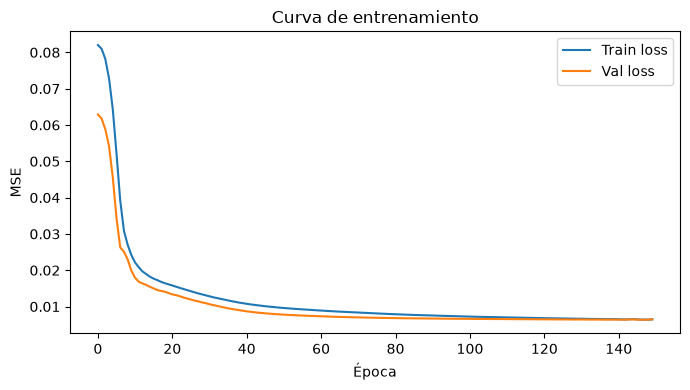

In [18]:
plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Curva de entrenamiento")
plt.legend()
plt.tight_layout()
plt.show()


## Evaluación 
Comparamos el error cuadrático medio entre la señal ruidosa y la limpia contra el error entre la señal reconstruida y la limpia (resultado del modelo). Esperamos que el segundo modelo sea mejor.

In [20]:
X_test_pred = autoencoder.predict(X_test_noisy, verbose=0)

mse_noisy_vs_clean = np.mean((X_test_noisy - X_test_clean) ** 2)
mse_recon_vs_clean = np.mean((X_test_pred - X_test_clean) ** 2)

print(f"MSE (ruidosa vs limpia):       {mse_noisy_vs_clean:.5f}")
print(f"MSE (reconstruida vs limpia):  {mse_recon_vs_clean:.5f}")
print(f"Reducción de error:            {(1 - mse_recon_vs_clean/mse_noisy_vs_clean) * 100:.1f}%")


MSE (ruidosa vs limpia):       0.02044
MSE (reconstruida vs limpia):  0.00854
Reducción de error:            58.2%


## Visualización entre la señal original, ruidosa y reconstruida.
Panel de 3 gráficos, mas una comparación superpuesta de varias ventanas para una vista general.


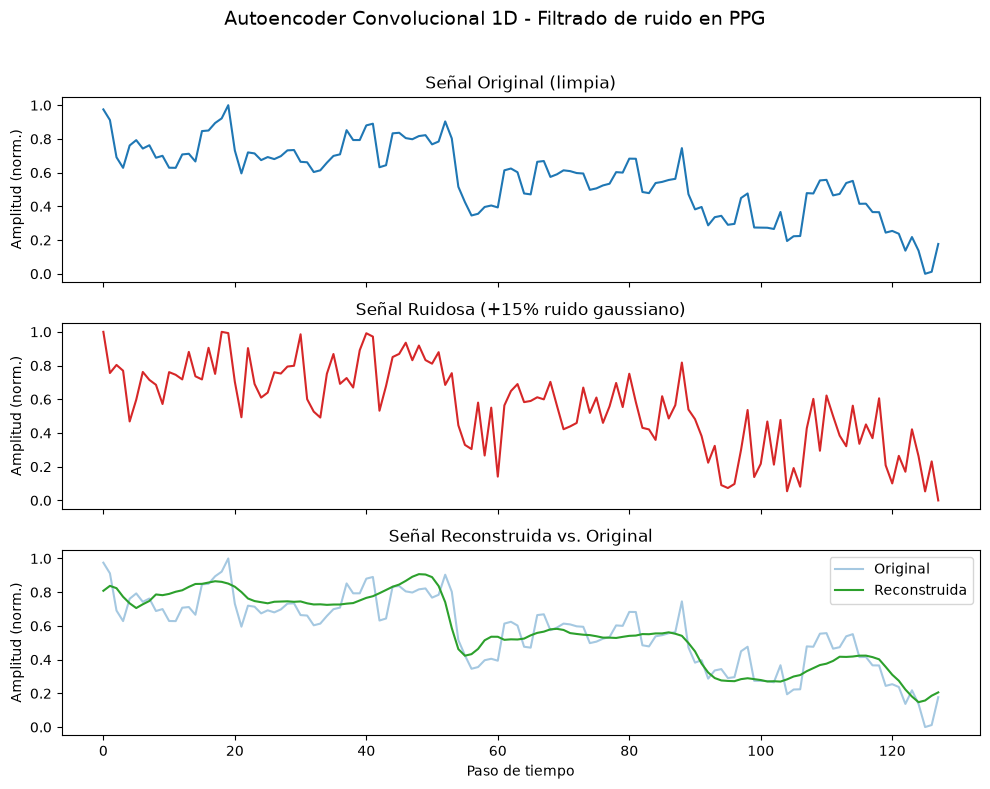

Figura guardada en outputs/figures/comparison_plot.png


In [21]:
os.makedirs("outputs/figures", exist_ok=True)

idx = 0  # cambia este índice para ver otras ventanas del set de test

original = X_test_clean[idx].squeeze()
noisy = X_test_noisy[idx].squeeze()
reconstructed = X_test_pred[idx].squeeze()

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True, sharey=True)

axes[0].plot(original, color="tab:blue")
axes[0].set_title("Señal Original (limpia)")
axes[0].set_ylabel("Amplitud (norm.)")

axes[1].plot(noisy, color="tab:red")
axes[1].set_title("Señal Ruidosa (15% ruido gaussiano)")
axes[1].set_ylabel("Amplitud (norm.)")

axes[2].plot(original, color="tab:blue", alpha=0.4, label="Original")
axes[2].plot(reconstructed, color="tab:green", label="Reconstruida")
axes[2].set_title("Señal Reconstruida vs. Original")
axes[2].set_xlabel("Paso de tiempo")
axes[2].set_ylabel("Amplitud (norm.)")
axes[2].legend(loc="upper right")

fig.suptitle("Autoencoder Convolucional 1D - Filtrado de ruido en PPG", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])

fig.savefig("outputs/figures/comparison_plot.png", dpi=200)
plt.show()

print("Figura guardada en outputs/figures/comparison_plot.png")


In [ ]:
## Guardamos el modelo entrenado
os.makedirs("outputs/models", exist_ok=True)
autoencoder.save("outputs/models/conv1d_ppg_denoising_autoencoder.keras")
print("Modelo guardado en outputs/models/")
